In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("german_credit_data.csv", index_col=0)
print("Dataset loaded!", df.shape)
print(df.columns.tolist())
print(df.head())

Dataset loaded! (1000, 10)
['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']
   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  Risk  
0         6             radio/TV  good  
1        48             radio/TV   bad  
2        12            education  good  
3        42  furniture/equipment  good  
4        24                  car   bad  


In [2]:
# Explore the dataset
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nRisk distribution:")
print(df['Risk'].value_counts())

Shape: (1000, 10)

Missing values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Risk distribution:
Risk
good    700
bad     300
Name: count, dtype: int64


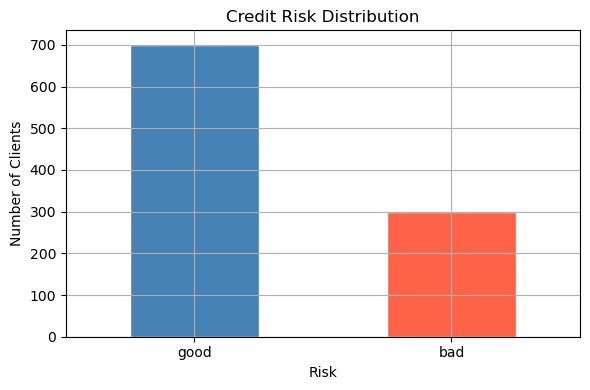

<Figure size 800x400 with 0 Axes>

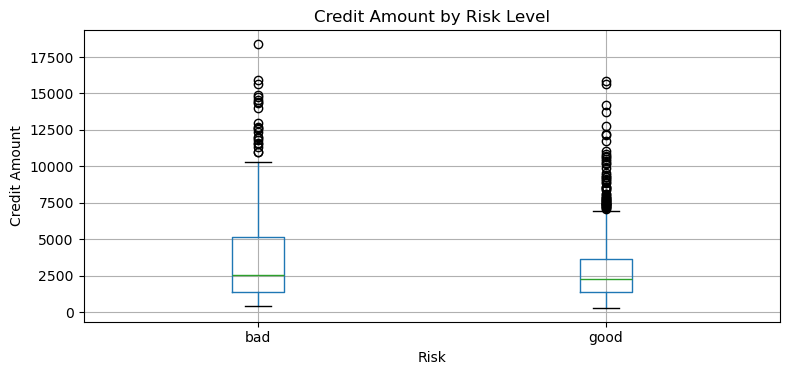

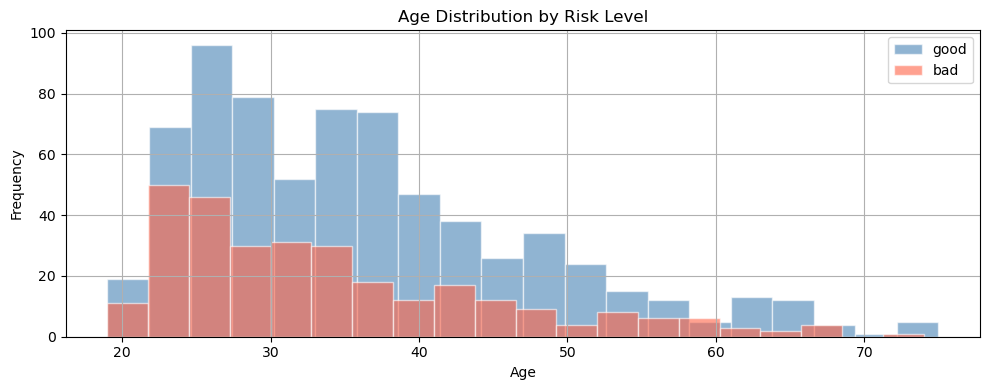

In [3]:
# Visualisation 1: Risk distribution
plt.figure(figsize=(6, 4))
df['Risk'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisation 2: Credit amount by risk
plt.figure(figsize=(8, 4))
df.boxplot(column='Credit amount', by='Risk', figsize=(8, 4))
plt.title("Credit Amount by Risk Level")
plt.suptitle("")
plt.xlabel("Risk")
plt.ylabel("Credit Amount")
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisation 3: Age distribution by risk
plt.figure(figsize=(10, 4))
for risk, color in zip(['good', 'bad'], ['steelblue', 'tomato']):
    subset = df[df['Risk'] == risk]['Age']
    plt.hist(subset, bins=20, alpha=0.6, color=color, label=risk, edgecolor='white')
plt.title("Age Distribution by Risk Level")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# Data preparation
# Fill missing values
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

# Encode categorical variables
le = LabelEncoder()
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Encode target variable
df_encoded['Risk'] = df_encoded['Risk'].map({'good': 0, 'bad': 1})

# Define features and target
X = df_encoded.drop('Risk', axis=1)
y = df_encoded['Risk']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nRisk distribution in training set:")
print(y_train.value_counts())

Training set size: (800, 9)
Testing set size: (200, 9)

Risk distribution in training set:
Risk
0    559
1    241
Name: count, dtype: int64


In [5]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Model trained successfully!

Accuracy: 75.5 %


c:\Users\marin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

   Good Risk       0.78      0.91      0.84       141
    Bad Risk       0.65      0.37      0.47        59

    accuracy                           0.76       200
   macro avg       0.71      0.64      0.66       200
weighted avg       0.74      0.76      0.73       200



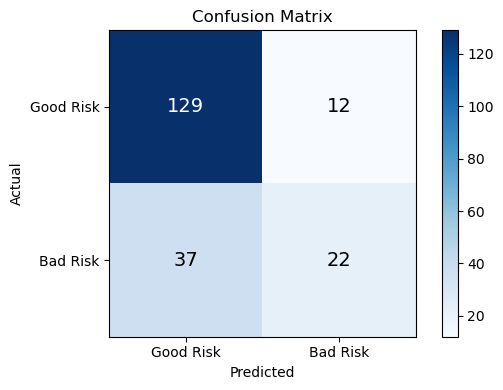

In [6]:
# Detailed model evaluation
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Good Risk', 'Bad Risk']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['Good Risk', 'Bad Risk'])
plt.yticks([0, 1], ['Good Risk', 'Bad Risk'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=14, color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Credit Risk Classification — Summary

## Objective
Predict whether a bank client has good or bad credit risk
using real financial and personal data.

## Dataset
- **Source:** German Credit Data (Kaggle)
- **Size:** 1,000 clients, 10 features
- **Target:** Risk (good/bad) — evaluated by credit specialists

## What I Did
- Explored the dataset and identified key patterns
- Filled missing values in Saving and Checking account columns
- Encoded categorical variables using LabelEncoder
- Split data: 80% training, 20% testing

## Model
Logistic Regression (scikit-learn)

## Results
| Metric | Value |
|--------|-------|
| Overall Accuracy | 75.5% |
| Good Risk Recall | 91% |
| Bad Risk Recall | 37% |

## Key Insights
- Clients with higher credit amounts tend to be higher risk
- Younger clients (20-30) represent the highest volume of bad risk
- Dataset is imbalanced: 70% good, 30% bad
- Imbalance explains why bad risk recall is lower

## Next Steps
- Apply SMOTE to balance the dataset
- Test Random Forest or XGBoost for better bad risk detection
- Tune decision threshold to improve bad risk recall